# AstroPySal Testing 

In [1]:
%load_ext autoreload
%autoreload 2
import healpy as hp 
import libpysal
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from AstroPySal import AstroPySal
from esda.moran import Moran, Moran_BV, Moran_Local, Moran_Local_BV
from matplotlib.colors import BoundaryNorm, ListedColormap

 [astropy.io.fits.verify]


/tmp/ipykernel_37749/4115942692.py:50: RuntimeWarning: invalid value encountered in log10
  np.log10(whamDat),


/tmp/ipykernel_37749/4115942692.py:88: RuntimeWarning: invalid value encountered in log10
  hp.mollview(np.log10(whamDatMasked), min = -1, max = 1.5, cmap = 'plasma', unit='Log(I/R)')


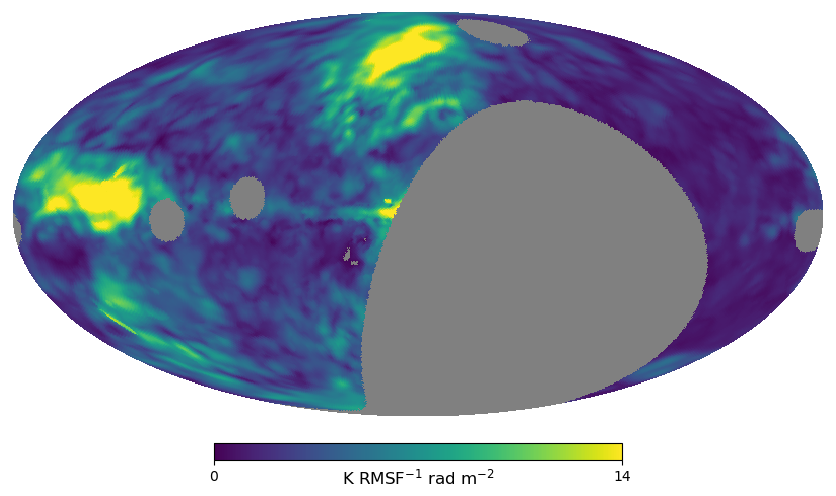

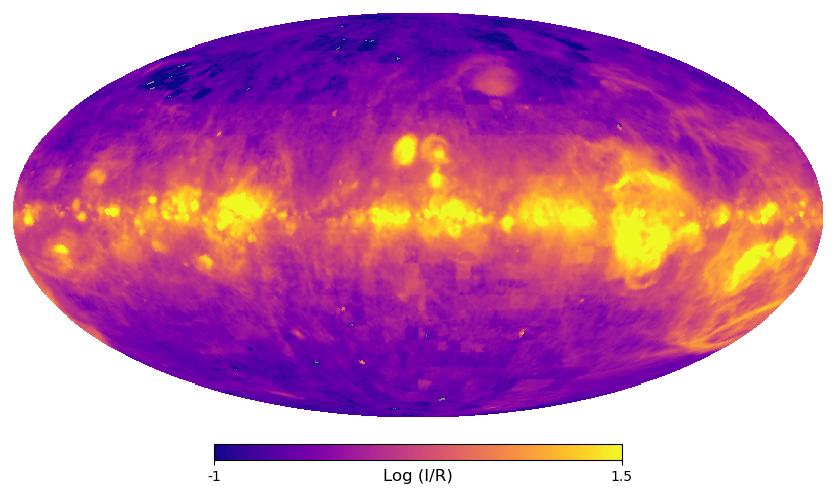

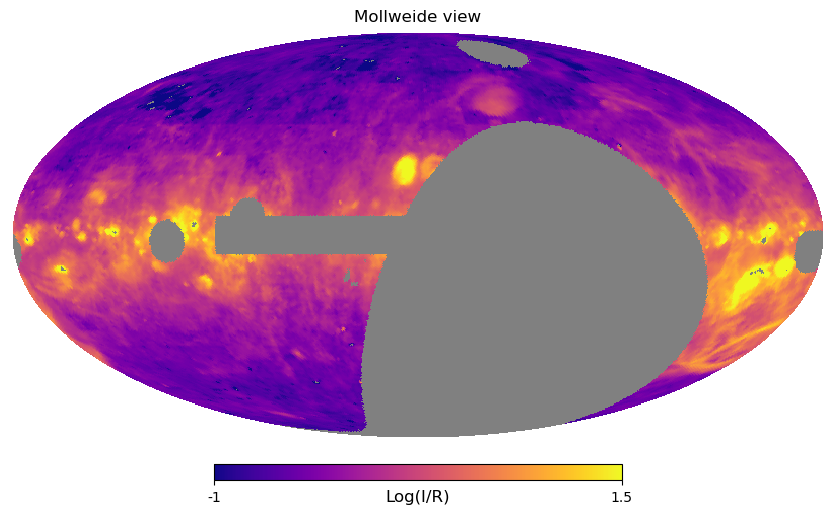

In [2]:
# replace the file path here with the path to whichever data you would like to analyze

fn1 = "/mnt/extra/ResearchSummer26/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_M0_gal.hpx.fits"
fn2 = "/mnt/extra/ResearchSummer26/WHAM/wham-ss-DR1-v161116-170912-grid.fits"

dragDatM0 = fits.getdata(fn1)
whamDatRaw = fits.getdata(fn2)


hp.mollview(
    dragDatM0,
    cbar=True,
    min=0,
    max=14,
    unit=r"K RMSF$^{-1}$ rad m$^{-2}$",
    title="",
)
plt.savefig(
    "/mnt/extra/ResearchSummer26/Code/figures/Polarized_intensity_dragons_presrdy"
)

from astropy.coordinates import SkyCoord
from reproject import reproject_to_healpix

hdu = fits.open(fn2)[0]
whamDat = hdu.data
whamHdr = hdu.header

wcsSpatial = WCS(whamHdr).celestial
nside = 128
nChannels = whamDat.shape[0]
nPix = 12 * (nside**2)

whamHpx = np.zeros((nChannels, nPix))
for i in range(nChannels):
    channelData = whamDat[i, :, :]

    whamHpxSlice, footprint = reproject_to_healpix(
        (channelData, wcsSpatial),
        coord_system_out="galactic",
        nside=128,
        order="bilinear",
    )

    whamHpx[i, :] = whamHpxSlice

whamDat = np.nansum(whamHpx, axis=0)

hp.mollview(
    np.log10(whamDat),
    max=1.5,
    min=-1,
    cmap="plasma",
    unit="Log (I/R)",
    title="",
    
)
plt.savefig(
    "/mnt/extra/ResearchSummer26/Code/figures/WHAM_Intensity_presrdy.png", dpi=500
)

# match WHAM to DRAGONS footprint
nside = 128
nPix = hp.nside2npix(nside)
allPixIdx = np.arange(nPix)
theta, phi = hp.pix2ang(nside, allPixIdx, nest=False)
galLat = 90.0 - np.degrees(theta)
galLong = np.degrees(phi)
nanMask = ~np.isfinite(dragDatM0) | ~np.isfinite(whamDat)
outlierMask = (
    (whamDat > np.nanpercentile(whamDat, 99.8))
    | (whamDat < 0)
    | (dragDatM0 > np.nanpercentile(dragDatM0, 100))
    | (dragDatM0 < 0)
)
badData = (galLong <= 90) & (galLat < 7) & (galLat >-7)
badMask = nanMask | outlierMask | badData

whamDatMasked = whamDat.copy()
dragDatM0Masked = dragDatM0.copy()

whamDatMasked[badMask] = hp.UNSEEN
dragDatM0Masked[badMask] = hp.UNSEEN

whamDatValid = whamDat[~badMask]
dragDatM0Valid = dragDatM0[~badMask]

hp.mollview(np.log10(whamDatMasked), min = -1, max = 1.5, cmap = 'plasma', unit='Log(I/R)')
plt.savefig('/mnt/extra/ResearchSummer26/Code/figures/whamM0_dragonfootprint.png', dpi = 500, bbox_inches='tight')

In [3]:
# create an analysis object
analysis = AstroPySal(nside=128, keepMask=~badMask)

# call on what was placed in the analysis object
print(analysis.nside)
# given as example, there is no value for these two fields right now
print(analysis.keepIds)
print(analysis.w)
print("-=-=--=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=")
# build the weights
w = analysis.build_healpix_weights()


# now check again
print(f"nside = {analysis.nside}")
print(f"IDs: {analysis.keepIds}")  # prints the stored IDs of analysis object pixels
print(
    f"Number of weighted pixels: {analysis.w.n}"
)  # prints the number of weighted pixels

128
None
None
-=-=--=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=


nside = 128
IDs: [     0      1      2 ... 195950 195951 195952]
Number of weighted pixels: 124217


## create a Local Indicators of Spatial Awareness (LISA) report of two maps

In [4]:
print(len(whamDatMasked))
print(len(dragDatM0Masked))
print(analysis.nside)
print(len(analysis.keepIds))

196608
196608
128
124217


In [5]:
# create a Local Indicators of Spatial Awareness (LISA) report of two maps
analysis.alpha = 0.1
lisaBV = analysis.lisa_bv_report(
    whamDatMasked,
    dragDatM0Masked,
    label="WHAM vs Dragons",
    permutations=999,
    significanceMethod="pysal",
)

WHAM vs Dragons      significant= 78287/124217   HH= 3720  LH=21927  LL=36183  HL=16457


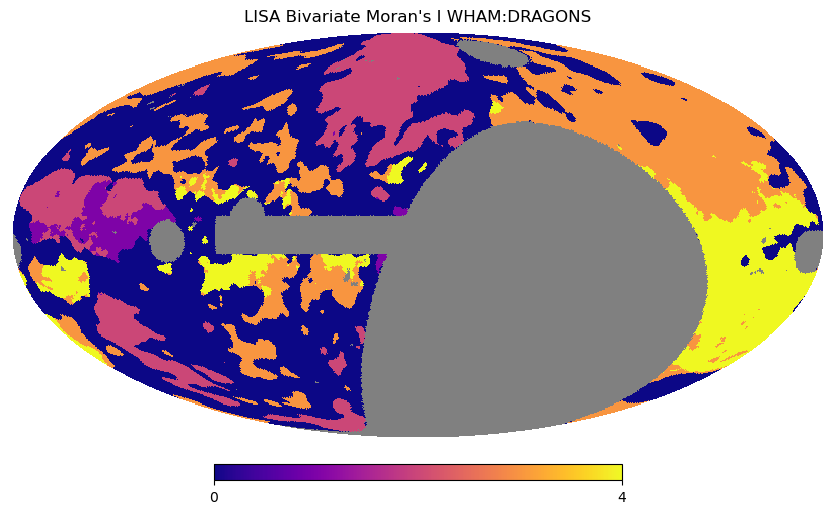

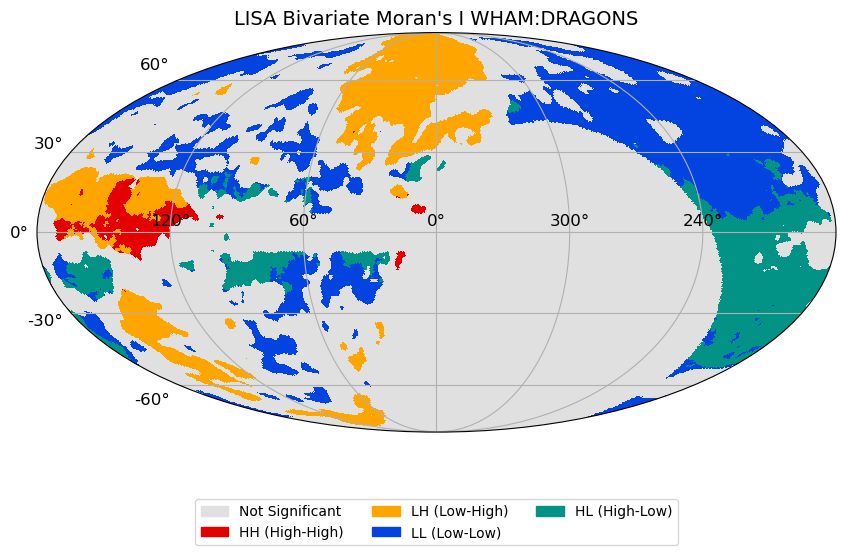

In [6]:
quadMap = analysis.build_lisa_bv_map(lisaBV, alpha=0.05)
# generated maps can be made using regular healpy functions like hp.mollview
# or hp.newvisufunc.projview
hp.mollview(quadMap, cmap="plasma", title="LISA Bivariate Moran's I WHAM:DRAGONS")

# they can also be plotted using a built-in function that makes use of projview and uses a
# custom colormap

analysis.plot_lisa_bv_map(quadMap, title="LISA Bivariate Moran's I WHAM:DRAGONS")
plt.savefig('/mnt/extra/ResearchSummer26/Code/figures/LISABV_WHAMM0_DRAGONSM0.png', dpi = 500, bbox_inches='tight')

In [7]:
#many significance tests rely on the function extract_lisa_bv_regions()
#so it's demonstration and test will go here 
print("=" * 70)
print("TEST: extract_lisa_bv_regions")
print("=" * 70)

regions = analysis.extract_lisa_bv_regions(
    lisaBV,
    alpha=0.1,
    quadrants=(1, 2, 3, 4),
    printRes=True,
)

assert isinstance(regions, list)

if len(regions) > 0:

    region = regions[0]

    requiredKeys = {
        "regionId",
        "size",
        "type",
        "composition",
        "centerGalLat",
        "centerGalLon",
        "pixIds",
    }

    assert requiredKeys.issubset(region.keys())
    assert region["size"] == len(region["pixIds"])
    assert -90 <= region["centerGalLat"] <= 90
    assert -180 <= region["centerGalLon"] <= 180

print("Test passed.")


TEST: extract_lisa_bv_regions
region   1  size=35225        type=mixed (dominant LL: {'HH': 0, 'LH': 0, 'LL': 22409, 'HL': 12816})
center=(l=-147.60, b=  22.37)
----------------------------------------------------------------
region   0  size=11225        type=mixed (dominant LH: {'HH': 4, 'LH': 11221, 'LL': 0, 'HL': 0})
center=(l=  16.93, b=  56.24)
----------------------------------------------------------------
region   7  size= 7493        type=mixed (dominant LL: {'HH': 0, 'LH': 0, 'LL': 6670, 'HL': 823})
center=(l=  86.98, b=  30.47)
----------------------------------------------------------------
region  23  size= 7384        type=mixed (dominant LH: {'HH': 3088, 'LH': 4296, 'LL': 0, 'HL': 0})
center=(l= 146.13, b=   8.75)
----------------------------------------------------------------
region  38  size= 4962        type=mixed (dominant LL: {'HH': 0, 'LH': 0, 'LL': 3308, 'HL': 1654})
center=(l=  80.13, b= -25.73)
----------------------------------------------------------------
r

In [8]:
print("=" * 70)
print("Testing compare_regions_to_surrogate()")
print("=" * 70)
analysis.alpha = 0.2

surrogateMaps = analysis.generate_gaussian_surrogates(
    dragDatM0Masked,
    nSurrogates=5,
)

print(f"Generated {len(surrogateMaps)} surrogate maps")

# run analysis
realRegions = analysis.extract_lisa_bv_regions(
    lisaBV,
)plot_lisa_bv_map
print(f"Extracted regions from real LISABV map.")

results = analysis.compare_regions_to_surrogates(
    whamDatMasked,
    realRegions,
    surrogateMaps,
)

print("Test passed")
print()

print("Returned Statistics: ")
print(results.keys())

print()
print("Largest region statistic:")
print(results["largestRegion"])

print()
print("Nubmer of surrogate realizations:")
print(len(results["largestRegion"]["distribution"]))


# test report_surrogate_statistics()
print("=" * 70)
print("Testing report_surrogate_statistics()")
print("=" * 70)

analysis.report_surrogate_statistics(results)

print()
print("Test Passed")


# Example: determining whether observed regions are unusual

largestRegion = results["largestRegion"]

print(f"Largest Observed region: {largestRegion['real']:.0f} pixels")

print(
    f"Average Surrogate largest region: "
    f"{largestRegion['mean']:.0f} +/- {largestRegion['std']:.0f} pixels"
)

print(f"Empirical p-value: {largestRegion['p']:.4f}")

if largestRegion["p"] < analysis.alpha:
    print(
        "The observed largest region is significantly larger than "
        "what is expected from Gaussian surrogate realizations."
    )
else:
    print(
        "The observed largest region is consistent with the Gaussian "
        "surrogate realizations."
    )

Testing compare_regions_to_surrogate()
Generated 5 surrogate maps
Extracted regions from real LISABV map.


SystemError: CPUDispatcher(<function compute_chunk at 0x713e842e3520>) returned a result with an exception set

In [13]:
# other significance tests, checking the quadrant abundance and region hierarchy
analysis.alpha = 0.2
surrogateMaps = analysis.generate_gaussian_surrogates(
    dragDatM0Masked,
    nSurrogates=5,
)

lisaBV = analysis.lisa_bv_report(
    whamDatMasked,
    dragDatM0Masked,
)

regions = analysis.extract_lisa_bv_regions(
    lisaBV,
)

quadrantResults = analysis.compare_quadrant_abundance(
    whamDatMasked,
    dragDatM0Masked,
    surrogateMaps,
)

analysis.report_quadrant_abundance(
    quadrantResults,
)

hierarchyResults = analysis.compare_region_hierarchy(
    whamDatMasked,
    regions,
    surrogateMaps,
)

analysis.report_region_hierarchy(
    hierarchyResults,
)

                     significant= 96463/128973   HH= 5026  LH=27012  LL=46810  HL=17615


                     significant=101442/128973   HH= 8413  LH=44157  LL=36371  HL=12501


                     significant= 98793/128973   HH= 8103  LH=38981  LL=40396  HL=11313


                     significant=100881/128973   HH=16293  LH=30603  LL=48620  HL= 5365


                     significant= 97531/128973   HH=10732  LH=38823  LL=37460  HL=10516


...

                     significant=100539/128973   HH= 8095  LH=42803  LL=36926  HL=12715


                     significant=100113/128973   HH= 8474  LH=39962  LL=40441  HL=11236


                     significant= 97854/128973   HH=15993  LH=29624  LL=47172  HL= 5065


                     significant= 98935/128973   HH=11013  LH=39671  LL=37668  HL=10583


                     significant= 98479/128973   HH= 5792  LH=45823  LL=30417  HL=16447
Region Hierarchy Test
  Rank        Real        Mean         Std           p
------------------------------------------------------------------------
     1       38464      6503.6      2016.3      0.1667
     2       12675      3266.2       637.2      0.1667
     3       11812      2418.6       542.2      0.1667
     4       10497      1617.4       243.9      0.1667
     5        7944      1240.2       260.1      0.1667
     6        4395      1023.8       211.0      0.1667
     7        1882       696.2       110.4      0.1667
     8        1325       593.0       100.5      0.1667
     9         947       441.4       137.4      0.1667
    10         623       347.6        84.0      0.1667


In [14]:
#next significance test will be persistence, it asks, does this region 
#survive increasingly stringent significance thresholds? 

print("="*70)
print("Testing compare_region_persistence()")
print("="*70)

persistence = analysis.compare_region_persistence(
    whamDatMasked, 
    dragDatM0Masked,
    alphas = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01],
)

print("Test passed. \n")
print("Returned keys:")
for key in persistence: 
    print(key)

print("="*70)
print("Example: persistence across significance thresholds")
print("="*70)

for alpha, largest, count in zip(
    persistence['alpha'], 
    persistence["largestRegion"],
    persistence["numberRegions"],
):
    print(
        f"alpha={alpha:5.2f}   "
        f"Largest Region={largest:6d}   "
        f"Number of Regions={count:4d}"
    )

Testing compare_region_persistence()


Test passed. 

Returned keys:
alpha
largestRegion
numberRegions
totalPixels
Example: persistence across significance thresholds
alpha= 0.50   Largest Region= 11665   Number of Regions=  50
alpha= 0.40   Largest Region= 11506   Number of Regions=  68
alpha= 0.30   Largest Region= 10958   Number of Regions=  80
alpha= 0.20   Largest Region= 10830   Number of Regions=  82
alpha= 0.10   Largest Region= 10590   Number of Regions=  81
alpha= 0.05   Largest Region= 10402   Number of Regions=  70
alpha= 0.02   Largest Region= 10183   Number of Regions=  56
alpha= 0.01   Largest Region=  9778   Number of Regions=  49


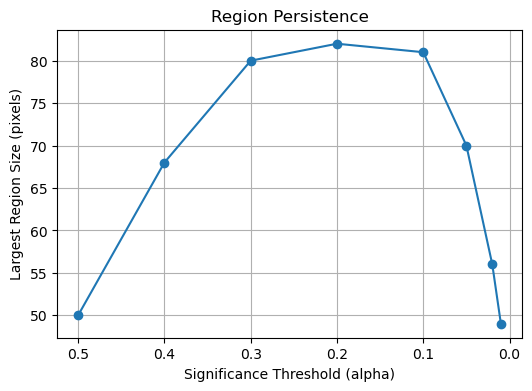

In [16]:
plt.figure(figsize=(6, 4))

plt.plot(
    persistence["alpha"],
    persistence["numberRegions"],
    marker="o",
)

plt.gca().invert_xaxis()

plt.xlabel("Significance Threshold (alpha)")
plt.ylabel("Largest Region Size (pixels)")
plt.title("Region Persistence")

plt.grid(True)

plt.show()

In [17]:
import contextlib
from pathlib import Path

outputPath = Path("surrogateAnalysisResults.txt")

with open(outputPath, "w") as outFile, contextlib.redirect_stdout(outFile):
    print("=" * 70)
    print("Testing compare_regions_to_surrogate()")
    print("=" * 70)

    surrogateMaps = analysis.generate_gaussian_surrogates(
        dragDatM0Masked,
        nSurrogates=100,
    )
    print(f"Generated {len(surrogateMaps)} surrogate maps")

    # run analysis
    realRegions = analysis.extract_lisa_bv_regions(
        lisaBV,
    )
    print("Extracted regions from real LISABV map.")

    results = analysis.compare_regions_to_surrogates(
        whamDatMasked,
        realRegions,
        surrogateMaps,
    )
    print("Test passed")
    print()

    print("Returned Statistics: ")
    print(results.keys())
    print()

    print("Largest region statistic:")
    print(results["largestRegion"])
    print()

    print("Number of surrogate realizations:")
    print(len(results["largestRegion"]["distribution"]))

    # test report_surrogate_statistics()
    print("=" * 70)
    print("Testing report_surrogate_statistics()")
    print("=" * 70)
    analysis.report_surrogate_statistics(results)
    print()
    print("Test Passed")

    # Example: determining whether observed regions are unusual
    largestRegion = results["largestRegion"]
    print(f"Largest Observed region: {largestRegion['real']:.0f} pixels")
    print(
        f"Average Surrogate largest region: "
        f"{largestRegion['mean']:.0f} +/- {largestRegion['std']:.0f} pixels"
    )
    print(f"Empirical p-value: {largestRegion['p']:.4f}")

    if largestRegion["p"] < analysis.alpha:
        print(
            "The observed largest region is significantly larger than "
            "what is expected from Gaussian surrogate realizations."
        )
    else:
        print(
            "The observed largest region is consistent with the Gaussian "
            "surrogate realizations."
        )

print(f"Results written to {outputPath.resolve()}")

SystemError: CPUDispatcher(<function compute_chunk at 0x7a08d7b6f010>) returned a result with an exception set

In [22]:
# the colour scheme can also be reversed when you want to match maps from one 
# direction to the other first create a different lisaBV object, 
#reversing the order of the two maps

lisaBVrev = analysis.lisa_bv_report(
    dragDatM0Masked, whamDatMasked, label="Dragons vs WHAM", permutations=999
)
quadMapRev = analysis.build_lisa_bv_map(lisaBVrev, alpha=0.05)

Dragons vs WHAM      significant= 92392/124217   HH= 4514  LH=16566  LL=41002  HL=30310


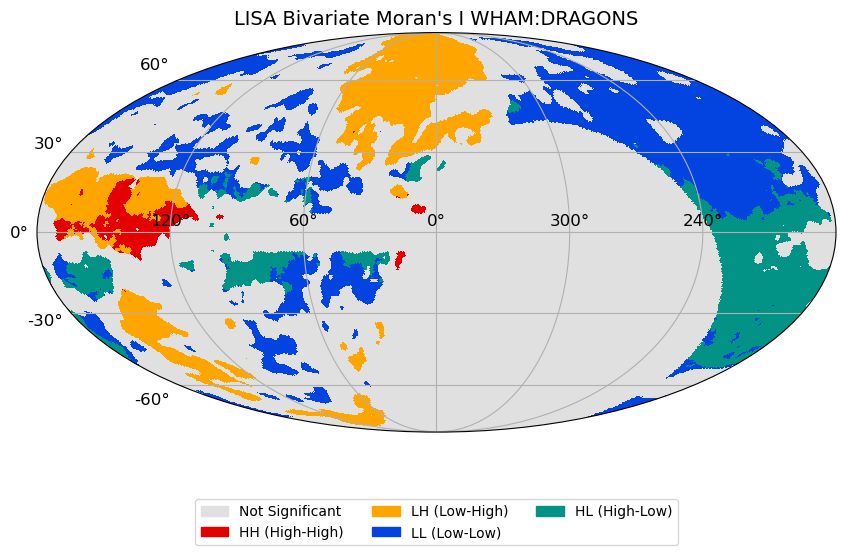

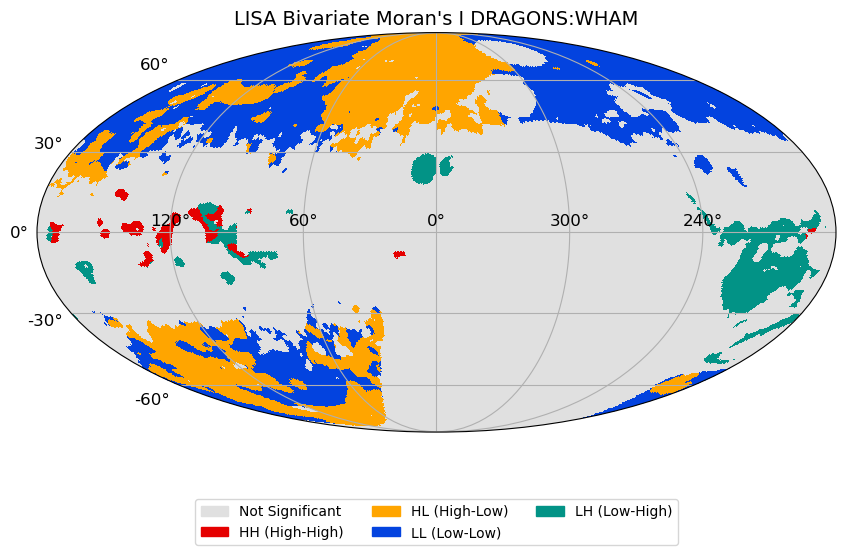

In [25]:
# then compare to the original specifying reverse=True, on the new map
analysis.plot_lisa_bv_map(quadMap, title="LISA Bivariate Moran's I WHAM:DRAGONS")
plt.savefig("/mnt/extra/ResearchSummer26/Code/figures/LISA_WHAMM0_DRAGONSM0.png", dpi=500, bbox_inches='tight')
analysis.plot_lisa_bv_map(
    quadMapRev, title="LISA Bivariate Moran's I DRAGONS:WHAM", reverse=True
)

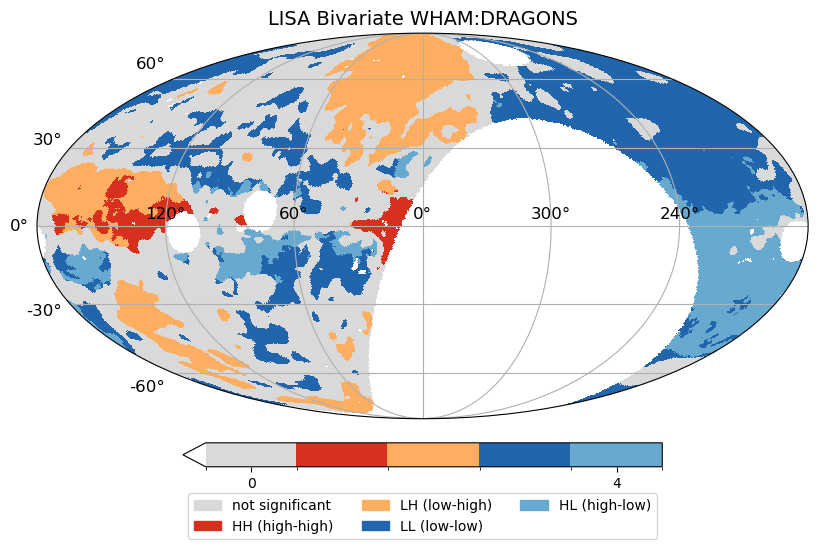

In [47]:
# it is also possible to make your own colormap, this is quite a bit more involved though
# discrete colormap: grey=not sig, red=HH, orange=LH, blue=LL, lightblue=HL
colors = ["#d9d9d9", "#d7301f", "#fdae61", "#2166ac", "#67a9cf"]
cmap = ListedColormap(colors)
cmap.set_under("white")  # hp.UNSEEN pixels
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = BoundaryNorm(bounds, cmap.N)

hp.newvisufunc.projview(
    quadMap,
    cmap=cmap,
    norm=norm,
    min=0,
    max=4,
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    # unit="cluster type",
    cb_orientation="horizontal",
    rot=0,
    title = 'LISA Bivariate WHAM:DRAGONS'
)

# manual legend since projview's colorbar won't show category labels cleanly
legendLabels = [
    "not significant",
    "HH (high-high)",
    "LH (low-high)",
    "LL (low-low)",
    "HL (high-low)",
]
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
plt.legend(
    handles, legendLabels, loc="lower center", bbox_to_anchor=(0.5, -0.33), ncol=3
)
plt.savefig(
    "/mnt/extra/ResearchSummer26/Code/figures/LISA_WHAM_DRAGONSM0_pres_rdy.png", dpi=500
)
plt.show()

In [8]:
# example use
print("\nExample: inspect the largest detected region")
if len(regions) > 0:
    region = regions[0]

    print(f"Region ID: {region['regionId']}")
    print(f"Size: {region['size']} pixels")
    print(f"Type: {region['type']}")
    print(f"Galactic longitude: {region['centerGalLon']:.2f} deg")
    print(f"Galactic latitude: {region['centerGalLat']:.2f} deg")

    print("\nQuadrant composition:")
    for quadrant, count in region["composition"].items():
        print(f"  {quadrant}: {count}")


Example: inspect the largest detected region
Region ID: 1
Size: 32145 pixels
Type: mixed (dominant LL: {'HH': 0, 'LH': 0, 'LL': 21538, 'HL': 10607})
Galactic longitude: -144.16 deg
Galactic latitude: 23.03 deg

Quadrant composition:
  HH: 0
  LH: 0
  LL: 21538
  HL: 10607


TEST: plot_region


Test passed.


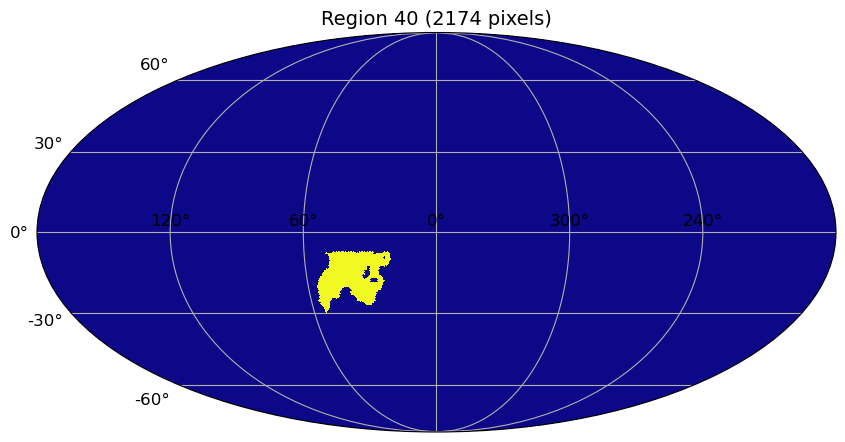

In [14]:
# plot region
# shows where on the sky the selected (indexed) region is located
print("=" * 70)
print("TEST: plot_region")
print("=" * 70)

if len(regions) > 0:

    region = regions[6]

    analysis.plot_region(region)

    print("Test passed.")


TEST: plot_region_cutout


/tmp/ipykernel_37749/1929164473.py:10: RuntimeWarning: invalid value encountered in log10
  analysis.plot_region_cutout(np.log10(whamDatMasked), region, cmap="plasma")


Test passed


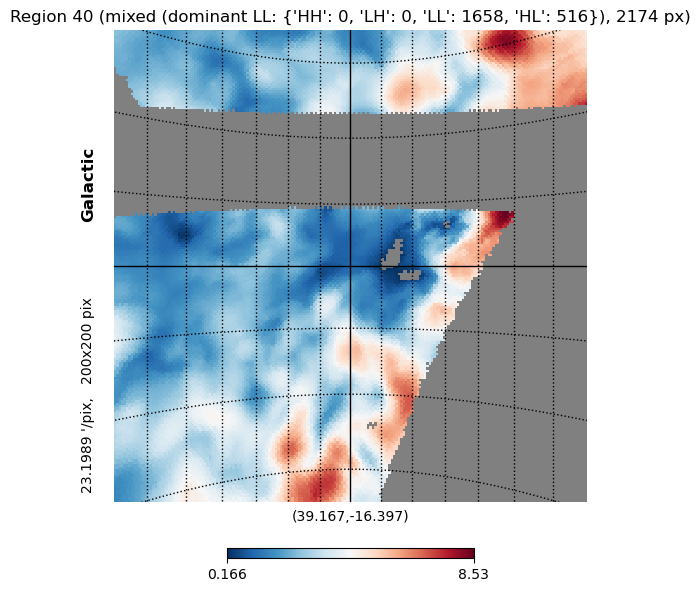

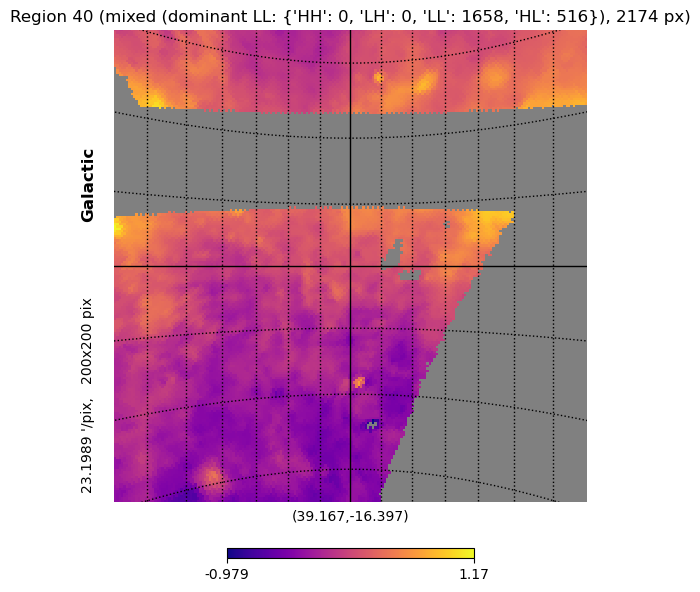

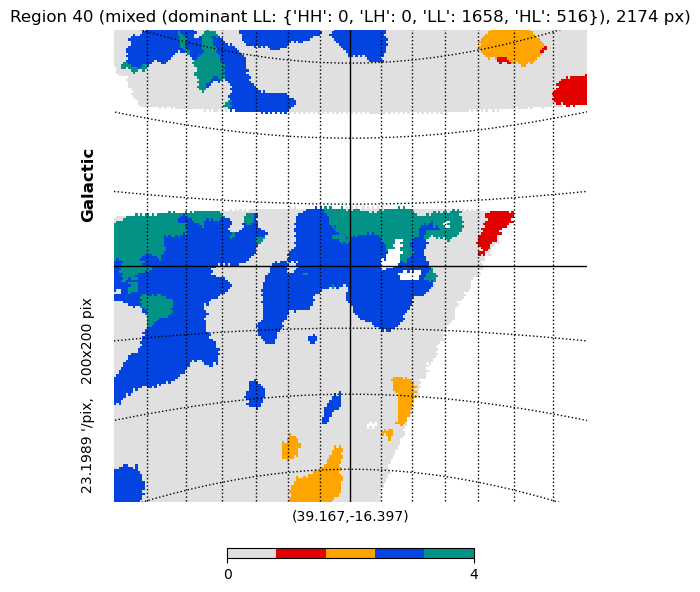

In [20]:
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
# plot_region_cutout()
# -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
print("\n" + "=" * 70)
print("TEST: plot_region_cutout")
print("=" * 70)

analysis.plot_region_cutout(dragDatM0Masked, region, cmap="RdBu_r")

analysis.plot_region_cutout(np.log10(whamDatMasked), region, cmap="plasma")

analysis.plot_region_cutout(
    quadMap,
    region,
    cmap=analysis.lisaCmap
)
plt.savefig(
     "/mnt/extra/ResearchSummer26/Code/figures/LISA_WHAMM0_DRAGONSM0_zoom.png", dpi=500, bbox_inches='tight'
)

print("Test passed")


Example: inspect a WHAM map around the region


/tmp/ipykernel_37749/1160568001.py:8: RuntimeWarning: invalid value encountered in log10
  np.log10(whamDatMasked),


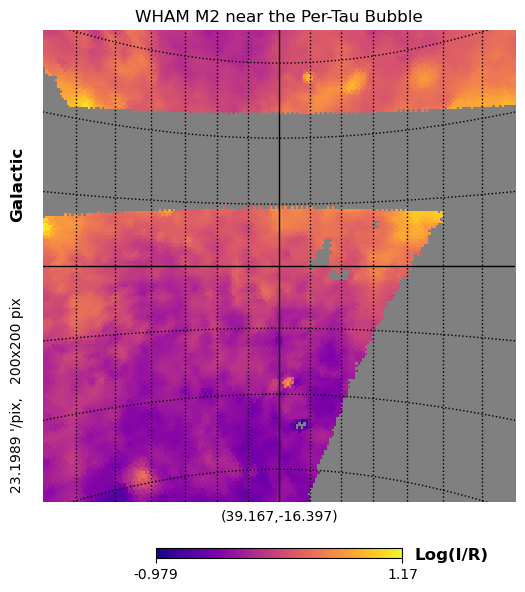

In [16]:
# =-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
# Example Use
# -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=--=-=
print("\nExample: inspect a WHAM map around the region")
if len(regions) > 0:

    analysis.plot_region_cutout(
        np.log10(whamDatMasked),
        region,
        paddingFactor=2.0,
        title="WHAM M2 near the Per-Tau Bubble",
        unit="Log(I/R)",
        cmap="plasma",
    )

In [35]:
# -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
# extract_region_cutout_data() tests
# -=-=-=-=-=-=-=-=-=-==-=-=-=-=-=-=-=-=-=-=-=-=
print("\n" + "=" * 70)
print("TEST: extract_region_cutout_data")
print("=" * 70)

if len(regions) > 0:
    dataDict = {
        "wham": whamDatMasked,
        "dragons": dragDatM0Masked,
    }

    cutout = analysis.extract_region_cutout_data(
        dataDict,
        region,
    )

    assert isinstance(cutout, dict)

    requiredKeys = {
        "pixIds",
        "inRegionMask",
        "data",
        "radiusDeg",
    }

    assert requiredKeys.issubset(cutout.keys())

    cutoutPixIds = cutout["pixIds"]
    inRegionMask = cutout["inRegionMask"]

    assert isinstance(cutoutPixIds, np.ndarray)
    assert isinstance(inRegionMask, np.ndarray)
    assert len(cutoutPixIds) == len(inRegionMask)

    assert set(cutout["data"].keys()) == {
        "wham",
        "dragons",
    }

    assert len(cutout["data"]["wham"]) == len(cutoutPixIds)
    assert len(cutout["data"]["dragons"]) == len(cutoutPixIds)

    assert cutout["radiusDeg"] >= 0

    regionPixIds = set(region["pixIds"])
    cutoutRegionPixIds = set(cutoutPixIds[inRegionMask])

    assert regionPixIds.issubset(cutoutRegionPixIds)

print("Test passed.")


TEST: extract_region_cutout_data
Test passed.


In [36]:
# -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
# example use
# ==-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
print("\nExample: extract WHAM and DRAGONS data around a region")

if len(regions) > 0:

    dataDict = {
        "wham": whamDatMasked,
        "dragons": dragDatM0Masked,
    }

    cutout = analysis.extract_region_cutout_data(
        dataDict,
        region,
        paddingFactor=2.0,
    )

    print(f"Cutout radius: {cutout['radiusDeg']:.2f} deg")
    print(f"Cutout pixels: {len(cutout['pixIds'])}")
    print(f"Region pixels:  " f"{np.sum(cutout['inRegionMask'])}")

    print("\nAvailable data:")

    for name, values in cutout["data"].items():
        print(f"  {name}:  " f"{len(values)} values")


Example: extract WHAM and DRAGONS data around a region
Cutout radius: 81.93 deg
Cutout pixels: 85089
Region pixels:  7944

Available data:
  wham:  85089 values
  dragons:  85089 values


In [37]:
regionMask = cutout["inRegionMask"]

whamRegion = cutout["data"]["wham"][regionMask]
dragonsRegion = cutout["data"]["dragons"][regionMask]

print("WHAM mean:", np.mean(whamRegion))
print("Dragons mean:", np.mean(dragonsRegion))

WHAM mean: 3.1007317066261004
Dragons mean: 10.037605568082585


LISA BV, Gaussian Surrogate:DRAGONS significant= 95928/128973   HH=16048  LH=17185  LL=28423  HL=34272


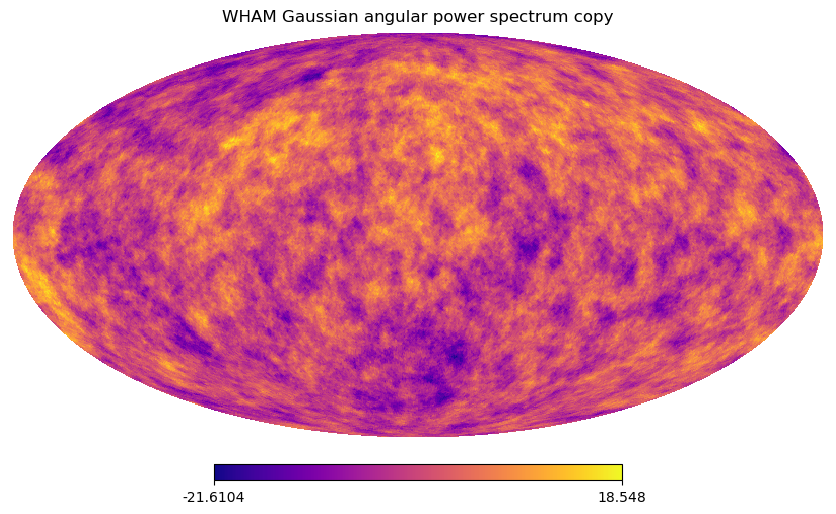

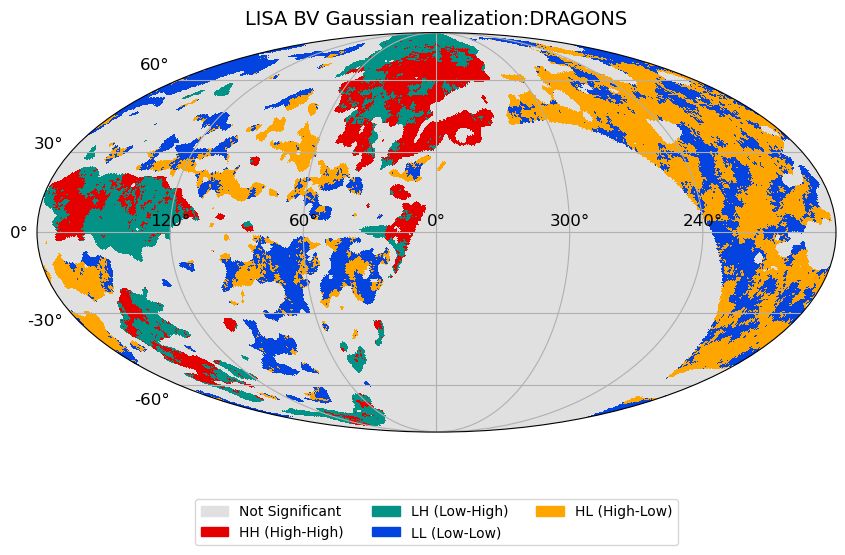

In [60]:
cl = hp.anafast(whamDatMasked) 
gaussSurr = hp.synfast(cl, 128)
hp.mollview(gaussSurr,
           title="WHAM Gaussian angular power spectrum copy",
           cmap = 'plasma')

# lisaBV = analysis.lisa_bv_report(
#     whamDatMasked,
#     dragDatM0Masked,
#     label="WHAM vs Dragons",
#     permutations=999,
#     significanceMethod="pysal",
# 


quadMap = analysis.build_lisa_bv_map(lisaBV, alpha=0.05)

gaussBVReport = analysis.lisa_bv_report(gaussSurr, dragDatM0Masked, label="LISA BV, Gaussian Surrogate:DRAGONS", 
                                        permutations=999,significanceMethod="pysal")

quadMap = analysis.build_lisa_bv_map(gaussBVReport, alpha = 0.05)
analysis.plot_lisa_bv_map(quadMap, title="LISA BV Gaussian realization:DRAGONS")

LISA BV, Gaussian Surrogate:DRAGONS significant= 96832/128973   HH= 7512  LH=42070  LL=32141  HL=15109


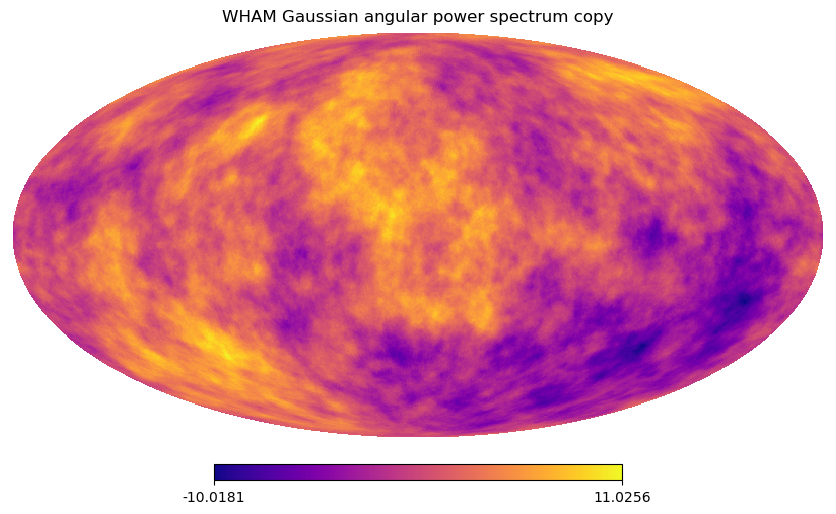

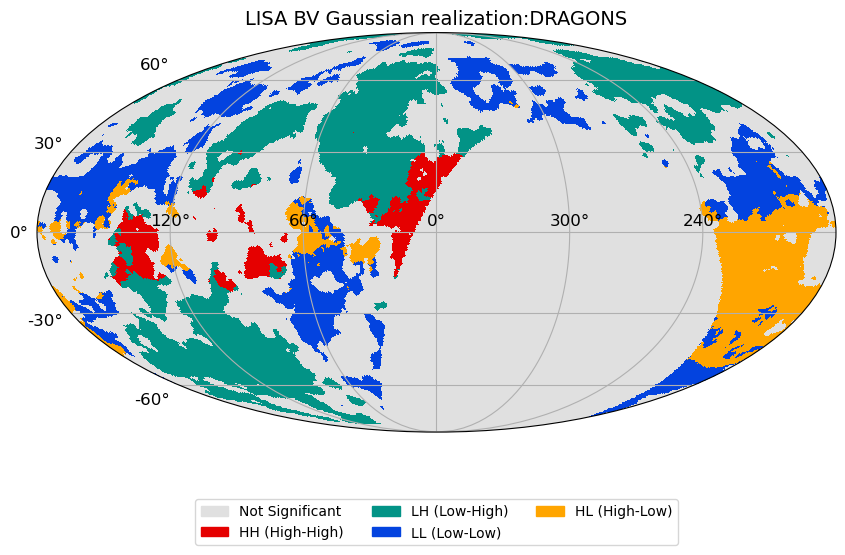

In [59]:
cl = hp.anafast(dragDatM0Masked) 
gaussSurr = hp.synfast(cl, 128)
hp.mollview(gaussSurr,
           title="WHAM Gaussian angular power spectrum copy",
           cmap = 'plasma')

# lisaBV = analysis.lisa_bv_report(
#     whamDatMasked,
#     dragDatM0Masked,
#     label="WHAM vs Dragons",
#     permutations=999,
#     significanceMethod="pysal",
# 


quadMap = analysis.build_lisa_bv_map(lisaBV, alpha=0.05)

gaussBVReport = analysis.lisa_bv_report(whamDatMasked, gaussSurr, label="LISA BV, Gaussian Surrogate:DRAGONS", 
                                        permutations=999,significanceMethod="pysal")

quadMap = analysis.build_lisa_bv_map(gaussBVReport, alpha = 0.05)
analysis.plot_lisa_bv_map(quadMap, title="LISA BV Gaussian realization:DRAGONS")

674/2481 boundary pixels have a masked-out neighbor (27.2%)


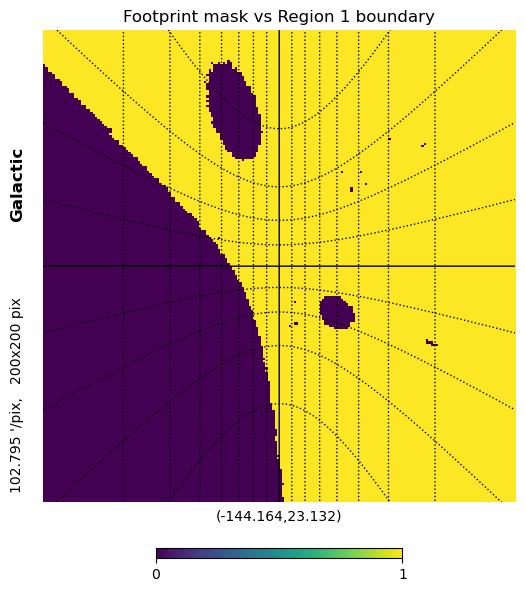

In [19]:
analysis.plot_footprint_vs_region(regions[0])
edgeCheck = analysis.check_footprint_edge_overlap(regions[0])

In [23]:
print("=" * 70)
print("Testing compare_regions_to_surrogate()")
print("=" * 70)

surrogateMaps = analysis.generate_gaussian_surrogates(
    dragDatM0Masked,
    nSurrogates=25,
)

print(f"Generated {len(surrogateMaps)} surrogate maps")

# run analysis
realRegions = analysis.extract_lisa_bv_regions(
    lisaBV,
)
print(f"Extracted regions from real LISABV map.")

results = analysis.compare_regions_to_surrogates(
    whamDatMasked,
    realRegions,
    surrogateMaps,
)

print("Test passed")
print()

print("Returned Statistics: ")
print(results.keys())

print()
print("Largest region statistic:")
print(results["largestRegion"])

print()
print("Nubmer of surrogate realizations:")
print(len(results["largestRegion"]["distribution"]))


# test report_surrogate_statistics()
print("=" * 70)
print("Testing report_surrogate_statistics()")
print("=" * 70)

analysis.report_surrogate_statistics(results)

print()
print("Test Passed")


# Example: determining whether observed regions are unusual

largestRegion = results["largestRegion"]

print(f"Largest Observed region: {largestRegion['real']:.0f} pixels")

print(
    f"Average Surrogate largest region: "
    f"{largestRegion['mean']:.0f} +/- {largestRegion['std']:.0f} pixels"
)

print(f"Empirical p-value: {largestRegion['p']:.4f}")

if largestRegion["p"] < analysis.alpha:
    print(
        "The observed largest region is significantly larger than "
        "what is expected from Gaussian surrogate realizations."
    )
else:
    print(
        "The observed largest region is consistent with the Gaussian "
        "surrogate realizations."
    )

Testing compare_regions_to_surrogate()


Generated 25 surrogate maps
Extracted regions from real LISABV map.


Test passed

Returned Statistics: 
dict_keys(['largestRegion', 'numberRegions', 'meanRegionSize', 'medianRegionSize', 'totalPixels', 'largestFraction'])

Largest region statistic:
{'real': np.int64(128973), 'mean': np.float64(11665.0), 'std': np.float64(0.0), 'p': np.float64(0.038461538461538464), 'distribution': array([11665, 11665, 11665, 11665, 11665, 11665, 11665, 11665, 11665,
       11665, 11665, 11665, 11665, 11665, 11665, 11665, 11665, 11665,
       11665, 11665, 11665, 11665, 11665, 11665, 11665])}

Nubmer of surrogate realizations:
25
Testing report_surrogate_statistics()
Region Significance Test
Largest Region
 Real:            128973.000
 Surrogate Mean:  11665.000
 Surrogate Std:   0.000
 Empirical P:     0.0385
Result significant
------------------------------------------------------------
Number of Regions
 Real:            1.000
 Surrogate Mean:  50.000
 Surrogate Std:   0.000
 Empirical P:     1.0000
Result insignificant
------------------------------------------------

In [31]:
latSurrogates = analysis.generate_latitude_aware_surrogates(
    dragDatM0Masked, nSurrogates=100
)

surrogateEdgeFractions = []
for surrogate in latSurrogates:
    surrogateValid = surrogate[analysis.keepIds]
    lisaSurrogate = Moran_Local_BV(
        whamDatMasked[analysis.keepIds].astype(np.float64),
        surrogateValid.astype(np.float64),
        analysis.w,
        permutations=analysis.permutations,
    )
    surrogateRegions = analysis.extract_lisa_bv_regions(lisaSurrogate, quadrants=(1, 4))
    if len(surrogateRegions) > 0:
        largestSurrogateRegion = surrogateRegions[0]
        edgeCheck = analysis.check_footprint_edge_overlap(largestSurrogateRegion)
        surrogateEdgeFractions.append(edgeCheck["fraction"])

print(f"Real region edge fraction: 0.272")
print(
    f"Surrogate mean: {np.mean(surrogateEdgeFractions):.3f} +/- {np.std(surrogateEdgeFractions):.3f}"
)

414/1462 boundary pixels have a masked-out neighbor (28.3%)


414/1462 boundary pixels have a masked-out neighbor (28.3%)


414/1462 boundary pixels have a masked-out neighbor (28.3%)


414/1462 boundary pixels have a masked-out neighbor (28.3%)


414/1462 boundary pixels have a masked-out neighbor (28.3%)


414/1462 boundary pixels have a masked-out neighbor (28.3%)


414/1462 boundary pixels have a masked-out neighbor (28.3%)


SystemError: CPUDispatcher(<function compute_chunk at 0x700f180f2b00>) returned a result with an exception set

In [41]:
print(np.array_equal(latSurrogates[0], latSurrogates[1]))
print(np.nanstd(latSurrogates[0] - latSurrogates[1]))

False
2.373384101247775


In [42]:
residual, trend = analysis.detrend_by_latitude(dragDatM0Masked)
validMask = residual != hp.UNSEEN
print(f"trend std:    {np.std(trend[validMask]):.4f}")
print(f"residual std: {np.std(residual[validMask]):.4f}")

trend std:    0.6504
residual std: 2.9891


In [43]:
whamResidual, whamTrend = analysis.detrend_by_latitude(whamDatMasked)
m0Residual, m0Trend = analysis.detrend_by_latitude(dragDatM0Masked)

# build surrogates from residual power spectrum only, no trend re-added
npix = hp.nside2npix(analysis.nside)
validMask = m0Residual != hp.UNSEEN
workingResidual = m0Residual.copy()
workingResidual[~validMask] = np.mean(workingResidual[validMask])
cl = hp.anafast(workingResidual, lmax=3 * analysis.nside - 1)

residualSurrogates = []
for i in range(100):
    s = hp.synfast(cl, nside=analysis.nside, lmax=3 * analysis.nside - 1)
    surrogate = np.full(npix, hp.UNSEEN)
    surrogate[validMask] = s[validMask]
    residualSurrogates.append(surrogate)

# real LISA-BV on residuals only, no trend
realLisaResidual = analysis.lisa_bv_report(
    whamResidual, m0Residual, label="residual-only"
)
realRegionsResidual = analysis.extract_lisa_bv_regions(
    realLisaResidual, quadrants=(1, 4)
)

residual-only        significant= 79012/128973   HH= 2270  LH=23304  LL=41413  HL=12025


In [44]:
print(f"analysis.keepIds count: {len(analysis.keepIds)}")

xCheck = whamResidual[analysis.keepIds]
yCheck = m0Residual[analysis.keepIds]

print(f"UNSEEN in xCheck: {np.sum(xCheck == hp.UNSEEN)}")
print(f"UNSEEN in yCheck: {np.sum(yCheck == hp.UNSEEN)}")
print(f"xCheck min/max: {xCheck.min()}, {xCheck.max()}")
print(f"yCheck min/max: {yCheck.min()}, {yCheck.max()}")

analysis.keepIds count: 128973
UNSEEN in xCheck: 0
UNSEEN in yCheck: 0
xCheck min/max: -3.3946013484937794, 82.97535445522226
yCheck min/max: -4.862003628737725, 21.611314714763814


In [45]:
# # Case 1: pure white noise, no spatial structure at all — should give ~alpha fraction significant
# whiteNoise1 = np.random.normal(size=len(whamResidual))
# whiteNoise2 = np.random.normal(size=len(whamResidual))
# whiteMap1 = np.full(hp.nside2npix(analysis.nside), hp.UNSEEN)
# whiteMap2 = np.full(hp.nside2npix(analysis.nside), hp.UNSEEN)
# whiteMap1[analysis.keepIds] = whiteNoise1
# whiteMap2[analysis.keepIds] = whiteNoise2
# lisaWhite = analysis.lisa_bv_report(whiteMap1, whiteMap2, label="white noise control")

# Case 2: synthetic smooth field, same power spectrum as your real residuals — should reproduce ~100%
lisaSmoothTest = analysis.lisa_bv_report(
    latSurrogates[0], latSurrogates[1], label="smooth surrogate vs surrogate"
)

smooth surrogate vs surrogate significant= 84109/128973   HH=23554  LH=16680  LL=24716  HL=19159


WHAM vs Dragons      significant= 26036/128973   HH= 5905  LH= 5852  LL= 7102  HL= 7177


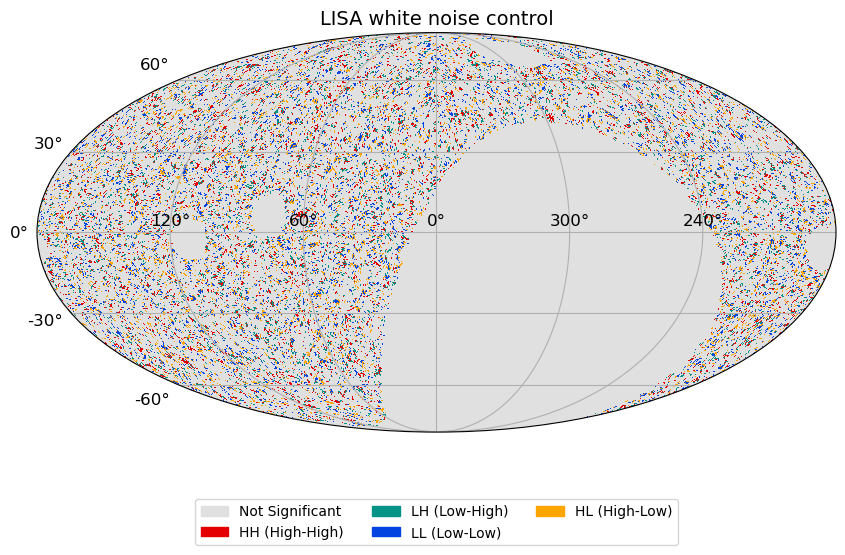

In [40]:
nValid = len(analysis.keepIds)
whiteNoise1 = np.random.normal(size=nValid)
whiteNoise2 = np.random.normal(size=nValid)

npix = hp.nside2npix(analysis.nside)
whiteMap1 = np.full(npix, hp.UNSEEN)
whiteMap2 = np.full(npix, hp.UNSEEN)
whiteMap1[analysis.keepIds] = whiteNoise1
whiteMap2[analysis.keepIds] = whiteNoise2

analysis.alpha = 0.1
# lisaWhite = analysis.lisa_bv_report(whiteMap1, whiteMap2, label="white noise control")
lisaWhite = analysis.lisa_bv_report(
    whiteMap1,
    whiteMap2,
    label="WHAM vs Dragons",
    permutations=999,
    significanceMethod="pysal",
)

quadMap = analysis.build_lisa_bv_map(lisaWhite, alpha=0.1)
analysis.plot_lisa_bv_map(quadMap, title="LISA white noise control")